# Tarea 1: Contestando preguntas sobre los datos  Free Weather API

**Universidad Yachay Tech**
Maestría en Ciencia de Datos - Fundamentos de Ciencia de Datos

**Autor:** Alexander Omar Fernández Pérez
**Fecha:** 26 de septiembre de 2026

---

### Objetivo

Descargar datos meteorológicos diarios desde la API de Open-Meteo, explorarlos con visualizaciones en Matplotlib y responder tres preguntas.

## 1.- Datos

In [1]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. Ciudades 
ciudades = [
    {"ciudad": "Quito",     "provincia": "Pichincha", "region": "Sierra",   "lat": -0.18, "lon": -78.47},
    {"ciudad": "Guayaquil", "provincia": "Guayas",    "region": "Costa",    "lat": -2.19, "lon": -79.89},
    {"ciudad": "Tena",      "provincia": "Napo",      "region": "Amazonía", "lat": -0.99, "lon": -77.81},
]

In [3]:
# 2. Variables diarias
variables = [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "precipitation_hours",
    "et0_fao_evapotranspiration",
    "shortwave_radiation_sum",
    "wind_speed_10m_max",
]

In [4]:
# 3. Parámetros de la consulta
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude":  [c["lat"] for c in ciudades],
    "longitude": [c["lon"] for c in ciudades],
    "start_date": "1995-01-01",
    "end_date":   "2025-12-31",
    "daily": ",".join(variables),
    "timezone": "America/Guayaquil",
}

In [5]:
# 4. Llamada a la API
respuesta = requests.get(url, params=params, timeout=120)
respuesta.raise_for_status()
datos = respuesta.json()  # lista: un resultado por ciudad

In [7]:
# 5. Convertir a una sola tabla
tablas = []
for info, resultado in zip(ciudades, datos):
    df = pd.DataFrame(resultado["daily"])
    df["ciudad"] = info["ciudad"]
    df["provincia"] = info["provincia"]
    df["region"] = info["region"]
    df["elevacion_m"] = resultado["elevation"]
    tablas.append(df)
 
clima = pd.concat(tablas, ignore_index=True)
clima = clima.rename(columns={"time": "fecha"})

In [8]:
# 6. Guardar en archivo local
os.makedirs("data", exist_ok=True)
clima.to_csv("data/clima_ecuador.csv", index=False)
 
print(clima.shape)
print(clima.head())

(33969, 13)
        fecha  temperature_2m_mean  temperature_2m_max  temperature_2m_min  \
0  1995-01-01                 12.1                14.3                10.6   
1  1995-01-02                 12.1                15.9                 9.4   
2  1995-01-03                 11.8                14.7                10.0   
3  1995-01-04                 11.3                15.4                 8.6   
4  1995-01-05                 10.8                14.0                 7.9   

   precipitation_sum  precipitation_hours  et0_fao_evapotranspiration  \
0               12.7                 22.0                        2.22   
1                6.7                 13.0                        2.82   
2               12.1                 24.0                        2.17   
3                3.2                 12.0                        3.09   
4               11.3                 13.0                        2.06   

   shortwave_radiation_sum  wind_speed_10m_max ciudad  provincia  region  \
0   

## Revisión de datos

In [9]:
clima = pd.read_csv("data/clima_ecuador.csv", parse_dates=["fecha"])
clima["anio"] = clima["fecha"].dt.year
clima["amplitud"] = clima["temperature_2m_max"] - clima["temperature_2m_min"]

# Nombres legibles y unidades de cada variable
VARS = {
    "temperature_2m_mean":        ("Temperatura media", "°C"),
    "temperature_2m_max":         ("Temperatura máxima", "°C"),
    "temperature_2m_min":         ("Temperatura mínima", "°C"),
    "precipitation_sum":          ("Lluvia diaria", "mm"),
    "precipitation_hours":        ("Horas con lluvia", "h"),
    "et0_fao_evapotranspiration": ("Evapotranspiración ET₀", "mm"),
    "shortwave_radiation_sum":    ("Radiación solar", "MJ/m²"),
    "wind_speed_10m_max":         ("Viento máximo", "km/h"),
}
cols = list(VARS)
nombres = [VARS[c][0] for c in cols]
unidades = [VARS[c][1] for c in cols]

# 1. Estructura general
print("Filas y columnas:", clima.shape)
print("Periodo:", clima["fecha"].min().date(), "a", clima["fecha"].max().date())
print("\nDías por ciudad:")
print(clima["ciudad"].value_counts())

# 2. Calidad: valores faltantes
faltantes = pd.DataFrame({
    "faltantes": clima[cols].isna().sum().values,
    "%": (clima[cols].isna().mean() * 100).round(2).values,
}, index=nombres)
display(faltantes)

# 3. Estadística descriptiva general (todas las ciudades)
desc = clima[cols].describe().T.round(2)
desc.index = nombres
desc.insert(0, "unidad", unidades)
desc.columns = ["unidad", "n", "media", "desv. est.", "mín", "p25", "mediana", "p75", "máx"]
display(desc)

# 4. Promedio diario por ciudad
por_ciudad = clima.groupby("ciudad")[cols].mean().T.round(1)
por_ciudad.index = nombres
por_ciudad.insert(0, "unidad", unidades)
display(por_ciudad[["unidad", "Quito", "Guayaquil", "Tena"]])

# 5. Indicadores clave por ciudad
resumen = clima.groupby("ciudad").agg(
    elevacion=("elevacion_m", "first"),
    temp_media=("temperature_2m_mean", "mean"),
    amplitud=("amplitud", "mean"),
    record_max=("temperature_2m_max", "max"),
    record_min=("temperature_2m_min", "min"),
    dias_lluvia=("precipitation_sum", lambda x: (x >= 1).mean() * 100),
    lluvia_max_dia=("precipitation_sum", "max"),
)
resumen["lluvia_anual"] = (clima.groupby(["ciudad", "anio"])["precipitation_sum"].sum()
                           .groupby("ciudad").mean())
resumen = resumen.round(1).T[["Quito", "Guayaquil", "Tena"]]
resumen.index = ["Elevación (m)", "Temperatura media (°C)", "Amplitud térmica diaria (°C)",
                 "Máxima récord (°C)", "Mínima récord (°C)", "% de días con lluvia (≥1 mm)",
                 "Lluvia máxima en un día (mm)", "Lluvia anual promedio (mm)"]
display(resumen)

Filas y columnas: (33969, 15)
Periodo: 1995-01-01 a 2025-12-31

Días por ciudad:
ciudad
Quito        11323
Guayaquil    11323
Tena         11323
Name: count, dtype: int64


,faltantes,%
Temperatura media,0,0.0
Temperatura máxima,0,0.0
Temperatura mínima,0,0.0
Lluvia diaria,0,0.0
Horas con lluvia,0,0.0
Evapotranspiración ET₀,0,0.0
Radiación solar,0,0.0
Viento máximo,0,0.0


,unidad,n,media,desv. est.,mín,p25,mediana,p75,máx
Temperatura media,°C,33969.0,19.60,5.64,9.00,12.40,22.40,23.80,29.40
Temperatura máxima,°C,33969.0,23.68,5.52,11.00,17.50,26.00,28.00,36.00
Temperatura mínima,°C,33969.0,16.59,5.90,2.40,9.60,19.00,21.10,25.90
Lluvia diaria,mm,33969.0,7.65,10.21,0.00,1.00,4.50,10.70,175.70
Horas con lluvia,h,33969.0,9.56,6.64,0.00,4.00,9.00,14.00,24.00
Evapotranspiración ET₀,mm,33969.0,3.15,0.83,0.47,2.59,3.14,3.72,6.10
Radiación solar,MJ/m²,33969.0,16.31,4.22,1.50,13.63,16.57,19.24,29.28
Viento máximo,km/h,33969.0,9.10,4.23,2.50,6.30,8.30,11.10,254.70


ciudad,unidad,Quito,Guayaquil,Tena
Temperatura media,°C,11.9,24.4,22.5
Temperatura máxima,°C,16.4,28.3,26.4
Temperatura mínima,°C,8.7,22.1,19.0
Lluvia diaria,mm,8.2,5.5,9.3
Horas con lluvia,h,10.3,7.6,10.8
Evapotranspiración ET₀,mm,3.0,3.2,3.3
Radiación solar,MJ/m²,17.2,15.0,16.8
Viento máximo,km/h,9.2,12.0,6.1


ciudad,Quito,Guayaquil,Tena
Elevación (m),2903.0,10.0,498.0
Temperatura media (°C),11.9,24.4,22.5
Amplitud térmica diaria (°C),7.7,6.2,7.4
Máxima récord (°C),22.9,36.0,32.9
Mínima récord (°C),2.4,17.2,12.7
% de días con lluvia (≥1 mm),85.9,55.4,85.5
Lluvia máxima en un día (mm),76.9,148.8,175.7
Lluvia anual promedio (mm),2992.3,2004.4,3391.0


## Preguntas de investigación

**Datos:** Open-Meteo, Historical Weather API, datos diarios de 1995 a 2025 para tres ciudades del Ecuador: **Quito** (Sierra, Pichincha), **Guayaquil** (Costa, Guayas) y **Tena** (Amazonía, Napo).

### P1. ¿Se han calentado las tres regiones del Ecuador entre 1995 y 2025?
Se obtiene la tendencia de la temperatura media anual en cada ciudad y se compara la evolución de las temperaturas máximas y mínimas.

### P2. ¿El fenómeno de El Niño afecta por igual a la Costa, la Sierra y la Amazonía?
Se calculan las anomalías de precipitación mensual (diferencia con el promedio histórico de cada mes) y se comparan los episodios de El Niño de **1997–98, 2015–16 y 2023–24** en las tres ciudades.

### P3. ¿Qué región enfrenta mayor déficit hídrico y en qué meses?
Se identifica en qué ciudad y en qué meses del año la demanda de agua de la atmósfera supera a la lluvia.

# Datos para visualizaciones

In [9]:

clima = pd.read_csv("data/clima_ecuador.csv", parse_dates=["fecha"])
clima["anio"] = clima["fecha"].dt.year
clima["mes"] = clima["fecha"].dt.month
 
CIUDADES = ["Quito", "Guayaquil", "Tena"]
COLORES = {"Quito": "#2a78d6", "Guayaquil": "#eb6834", "Tena": "#1baf7a"}
MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
AZUL, ROJO = "#2a78d6", "#e34948"
 
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})
os.makedirs("figuras", exist_ok=True)
 
# Tabla mensual: temperatura = promedio; lluvia y ET0 = suma del mes
mensual = (clima.groupby(["ciudad", "anio", "mes"])
           .agg(temp=("temperature_2m_mean", "mean"),
                lluvia=("precipitation_sum", "sum"),
                et0=("et0_fao_evapotranspiration", "sum"))
           .reset_index())
mensual["fecha"] = pd.to_datetime(dict(year=mensual["anio"], month=mensual["mes"], day=1))
mensual["balance"] = mensual["lluvia"] - mensual["et0"]
 
# Anomalías: diferencia con el promedio 1995-2025 del mismo mes y ciudad
prom = mensual.groupby(["ciudad", "mes"])[["temp", "lluvia"]].transform("mean")
mensual["anom_temp"] = mensual["temp"] - prom["temp"]
mensual["anom_lluvia"] = mensual["lluvia"] - prom["lluvia"]

## Gráfico 1 Heatmap de anomalías de temperatura (año x mes)

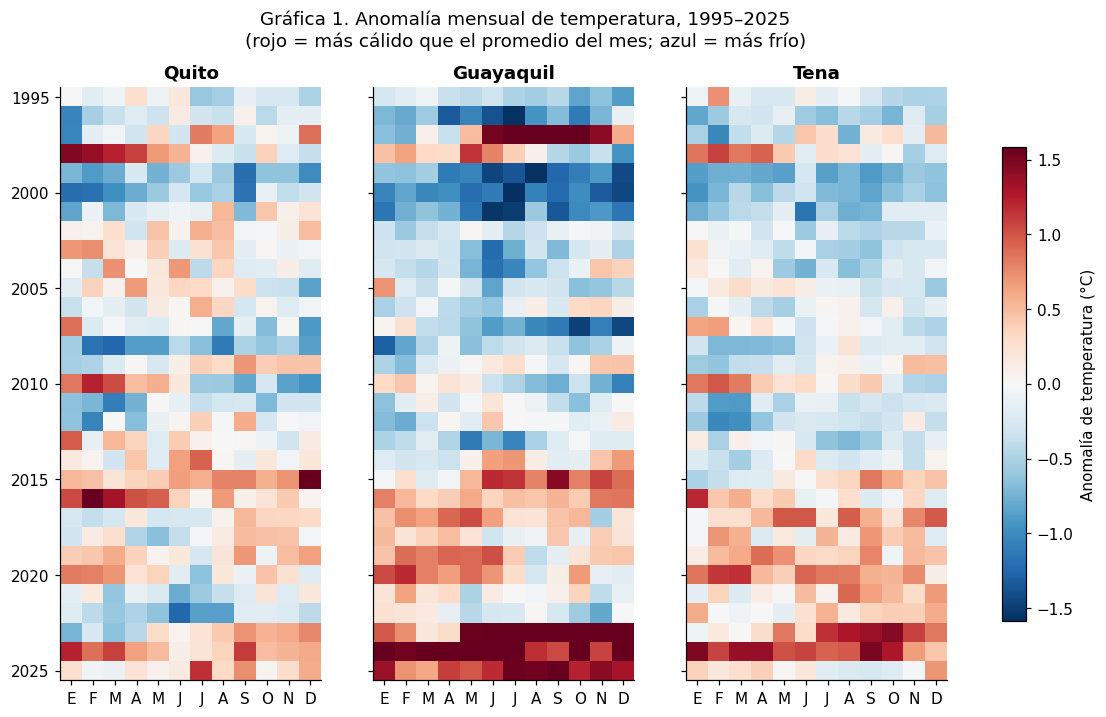

In [10]:

# %% Gráfica 1 (P1): Heatmap de anomalías de temperatura (año x mes)
lim = mensual["anom_temp"].abs().quantile(0.98)
fig, axes = plt.subplots(1, 3, figsize=(13, 7), sharey=True)
for ax, c in zip(axes, CIUDADES):
    m = mensual[mensual["ciudad"] == c].pivot(index="anio", columns="mes", values="anom_temp")
    im = ax.imshow(m, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    ax.set_title(c, fontweight="bold")
    ax.set_xticks(range(12), [x[0] for x in MESES])
    ax.set_yticks(range(0, len(m), 5), m.index[::5])
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8, label="Anomalía de temperatura (°C)")
fig.suptitle("Gráfica 1. Anomalía mensual de temperatura, 1995–2025\n"
             "(rojo = más cálido que el promedio del mes; azul = más frío)", x=0.45)
fig.savefig("figuras/01_heatmap_anomalias_temp.png", bbox_inches="tight")
plt.show()
 

## Gráfico 2 Tendencia de máximas y mínimas (°C por década)

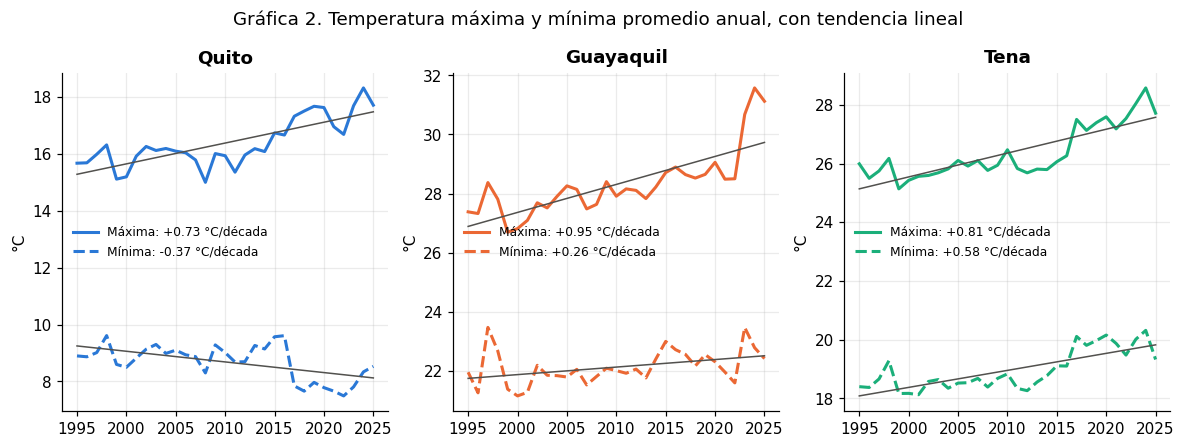

variable,Máxima,Mínima
ciudad,,
Guayaquil,0.95,0.26
Quito,0.73,-0.37
Tena,0.81,0.58


In [11]:

# %% Gráfica 2 (P1): Tendencia de máximas y mínimas (°C por década)
anual = clima.groupby(["ciudad", "anio"])[["temperature_2m_max", "temperature_2m_min"]].mean().reset_index()
anual = anual[anual["anio"] <= 2025]
 
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)
tendencias = []
for ax, c in zip(axes, CIUDADES):
    d = anual[anual["ciudad"] == c]
    for var, nombre, estilo in [("temperature_2m_max", "Máxima", "-"), ("temperature_2m_min", "Mínima", "--")]:
        x, y = d["anio"], d[var]
        pend, inter = np.polyfit(x, y, 1)
        ax.plot(x, y, estilo, color=COLORES[c], lw=2, label=f"{nombre}: {pend*10:+.2f} °C/década")
        ax.plot(x, pend * x + inter, color="#52514e", lw=1)
        tendencias.append({"ciudad": c, "variable": nombre, "°C por década": round(pend * 10, 2)})
    ax.set_title(c, fontweight="bold")
    ax.set_ylabel("°C")
    ax.legend(frameon=False, fontsize=8, loc="center left")
fig.suptitle("Gráfica 2. Temperatura máxima y mínima promedio anual, con tendencia lineal", y=1.02)
fig.savefig("figuras/02_tendencia_max_min.png", bbox_inches="tight")
plt.show()
 
pd.DataFrame(tendencias).pivot(index="ciudad", columns="variable", values="°C por década")

## Gráfico 3 Lluvia y episodios de El Niño

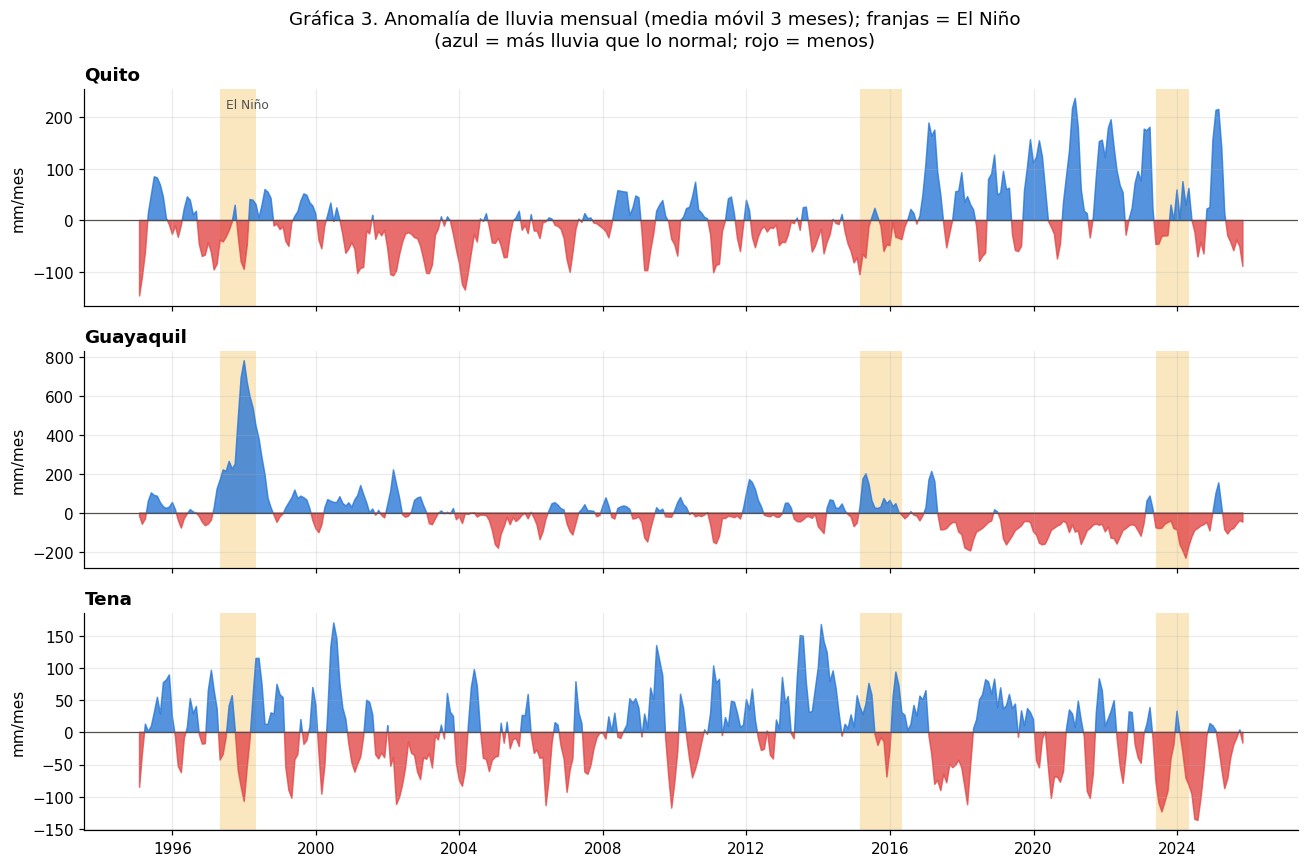

ciudad,Quito,Guayaquil,Tena
1997–1998,-18.7,434.8,-5.2
2015–2016,-30.6,67.4,24.6
2023–2024,3.3,-111.6,-59.9


In [12]:
 
# %% Gráfica 3 (P2): Anomalía de lluvia y episodios de El Niño
EL_NINO = [("1997-05", "1998-05"), ("2015-03", "2016-05"), ("2023-06", "2024-05")]
 
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, c in zip(axes, CIUDADES):
    d = mensual[mensual["ciudad"] == c].set_index("fecha")["anom_lluvia"]
    suav = d.rolling(3, center=True).mean()  # media móvil de 3 meses
    for ini, fin in EL_NINO:
        ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color="#eda100", alpha=0.25, lw=0)
    ax.fill_between(suav.index, suav, 0, where=suav >= 0, color=AZUL, alpha=0.8, interpolate=True)
    ax.fill_between(suav.index, suav, 0, where=suav < 0, color=ROJO, alpha=0.8, interpolate=True)
    ax.axhline(0, color="#52514e", lw=0.8)
    ax.set_title(c, loc="left", fontweight="bold")
    ax.set_ylabel("mm/mes")
axes[0].text(pd.Timestamp("1997-07"), axes[0].get_ylim()[1] * 0.85, "El Niño", fontsize=8, color="#52514e")
fig.suptitle("Gráfica 3. Anomalía de lluvia mensual (media móvil 3 meses); franjas = El Niño\n"
             "(azul = más lluvia que lo normal; rojo = menos)")
fig.tight_layout()
fig.savefig("figuras/03_anomalia_lluvia_el_nino.png", bbox_inches="tight")
plt.show()
 
# Resumen: anomalía promedio durante cada El Niño
filas = []
for ini, fin in EL_NINO:
    sel = mensual[(mensual["fecha"] >= ini) & (mensual["fecha"] <= fin)]
    fila = sel.groupby("ciudad")["anom_lluvia"].mean().round(1)
    fila.name = f"{ini[:4]}–{fin[:4]}"
    filas.append(fila)
pd.DataFrame(filas)[CIUDADES]  # mm/mes sobre (+) o bajo (−) lo normal
 

## Gráfico 4 Balance hídrico promedio por mes (lluvia − ET0)

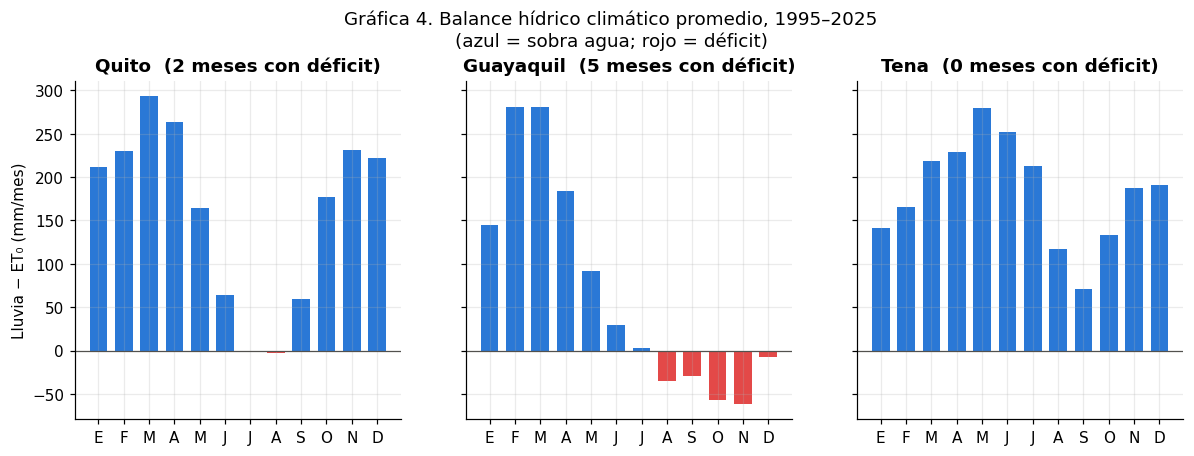

ciudad,Quito,Guayaquil,Tena
mes,,,
1,212.1,145.0,140.8
2,230.4,280.3,165.7
3,293.5,281.1,218.3
4,263.8,184.1,228.7
5,164.2,91.8,280.1
6,64.4,29.9,251.8
7,-0.4,2.8,213.1
8,-2.9,-35.0,116.8
9,59.2,-29.8,71.2


In [13]:
 
# %% Gráfica 4 (P3): Balance hídrico promedio por mes (lluvia − ET0)
bal = mensual.groupby(["ciudad", "mes"])["balance"].mean().unstack(0)
 
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, c in zip(axes, CIUDADES):
    y = bal[c]
    colores = [AZUL if v >= 0 else ROJO for v in y]
    ax.bar(range(1, 13), y, color=colores, width=0.7)
    ax.axhline(0, color="#52514e", lw=0.8)
    ax.set_xticks(range(1, 13), [x[0] for x in MESES])
    ax.set_title(f"{c}  ({(y < 0).sum()} meses con déficit)", fontweight="bold")
axes[0].set_ylabel("Lluvia − ET₀ (mm/mes)")
fig.suptitle("Gráfica 4. Balance hídrico climático promedio, 1995–2025\n"
             "(azul = sobra agua; rojo = déficit)", y=1.04)
fig.savefig("figuras/04_balance_hidrico.png", bbox_inches="tight")
plt.show()
 
bal.round(1)[CIUDADES]

## Gráfico 5 "Reloj" anual de la lluvia (barras polares)

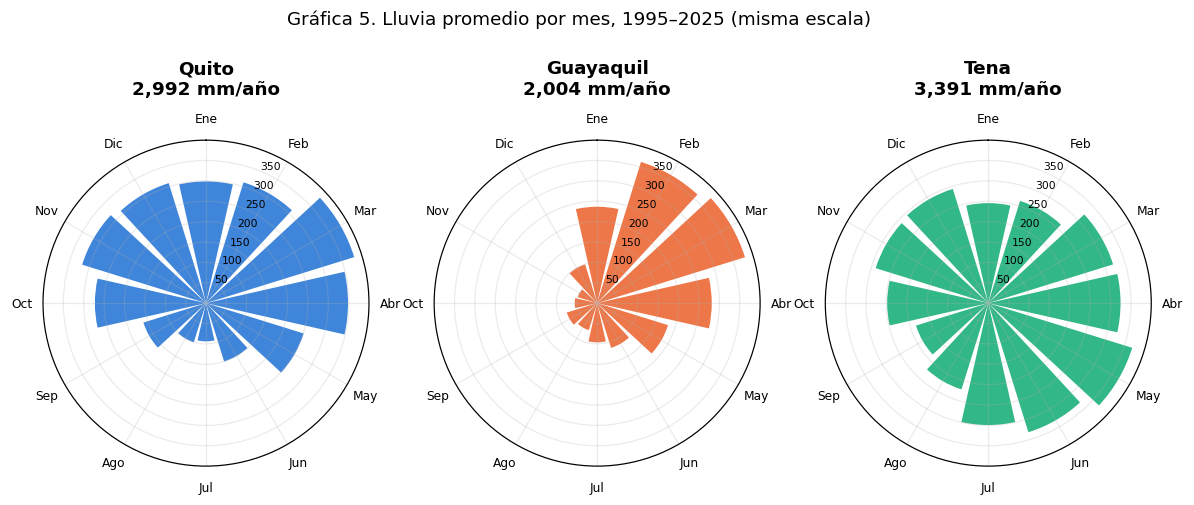

In [14]:

# %% Gráfica 5 (contexto): "Reloj" anual de la lluvia (barras polares)
lluvia_mes = mensual.groupby(["ciudad", "mes"])["lluvia"].mean().unstack(0)
ang = np.linspace(0, 2 * np.pi, 12, endpoint=False)
rmax = lluvia_mes.values.max() * 1.05
 
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), subplot_kw={"projection": "polar"})
for ax, c in zip(axes, CIUDADES):
    ax.bar(ang, lluvia_mes[c], width=2 * np.pi / 12 * 0.85, color=COLORES[c], alpha=0.9)
    ax.set_theta_zero_location("N")   # enero arriba
    ax.set_theta_direction(-1)        # sentido del reloj
    ax.set_xticks(ang, MESES, fontsize=8)
    ax.set_ylim(0, rmax)              # misma escala en las 3 ciudades
    ax.tick_params(axis="y", labelsize=7)
    ax.set_title(f"{c}\n{lluvia_mes[c].sum():,.0f} mm/año", fontweight="bold", pad=12)
fig.suptitle("Gráfica 5. Lluvia promedio por mes, 1995–2025 (misma escala)", y=1.05)
fig.savefig("figuras/05_reloj_lluvia.png", bbox_inches="tight")
plt.show()